## Link Video
### https://drive.google.com/drive/folders/1v1En2xqdBHOVpnJODKBRemMxlZTXfk8y?usp=sharing

# **3. Data Generation using GAN (Modified Model)**

## Import Library

In [ ]:
from zipfile import ZipFile
import tensorflow as tf
import pandas as pd
import numpy as np
import os
import cv2
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.optimizers import Adam
from matplotlib import pyplot as plt
from tensorflow.keras.layers import Input, Dense, Reshape, Conv2D, Conv2DTranspose, Activation, LeakyReLU, Flatten, MaxPooling2D, UpSampling2D, Cropping2D, BatchNormalization
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras import layers
from tensorflow.keras.layers import Dropout
from tensorflow.keras.preprocessing.image import array_to_img
from scipy.linalg import sqrtm

## Extract File (Because In Colab)

In [ ]:
zip_path = '/content/B_23.zip'
extract_path = '/content/B_23'

with ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

def loadFile(folder_path='/content/B_23', size=(100, 100)):
    images = []
    valid_extensions = ('.jpg', '.png', '.jpeg')

    for filename in os.listdir(folder_path):
        if filename.lower().endswith(valid_extensions):
            img_path = os.path.join(folder_path, filename)
            img = cv2.imread(img_path)
            if img is None:
                continue
            img = cv2.resize(img, size)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = img.astype(np.float32) / 127.5 - 1.0
            images.append(img)

    return np.array(images)

real_images = loadFile()
print("Images loaded:", real_images.shape)

Images loaded: (0,)


## Read Data

In [ ]:
def loadFile(folder_path='B_23', size=(100, 100)):
    images = []
    valid_extensions = ('.jpg', '.png', '.jpeg')

    for filename in os.listdir(folder_path):
        if filename.lower().endswith(valid_extensions):
            img_path = os.path.join(folder_path, filename)
            img = cv2.imread(img_path)
            if img is None:
                continue

            img = cv2.resize(img, size)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = img.astype(np.float32) / 127.5 - 1.0
            images.append(img)

    return np.array(images)

In [ ]:
real_images = loadFile('B_23/B_23', size=(100, 100))

## Show Image

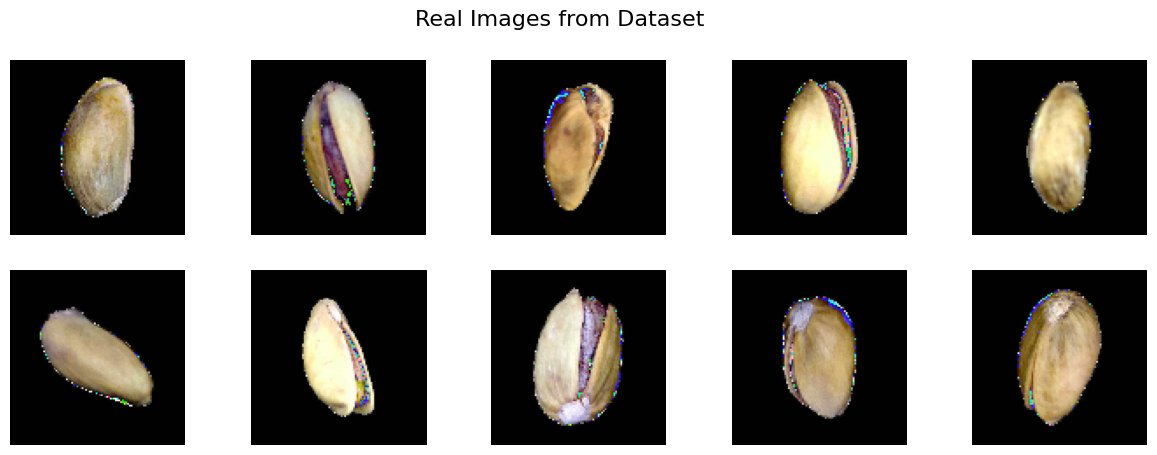

In [ ]:
def plot_real_images(images, num_images=10):
    plt.figure(figsize=(15, 5))
    for i in range(num_images):
        plt.subplot(2, num_images // 2, i + 1)
        plt.imshow((images[i] * 255).astype(np.uint8))
        plt.axis('off')
    plt.suptitle('Real Images from Dataset', fontsize=16)
    plt.show()

plot_real_images(real_images, num_images=10)

## Generator Model

In [ ]:
def build_generator(noise_dim=100):
    model = Sequential()

    model.add(Dense(25 * 25 * 128, input_dim=noise_dim))
    model.add(Reshape((25, 25, 128)))
    model.add(BatchNormalization())
    model.add(LeakyReLU(0.2))

    model.add(UpSampling2D(size=(2, 2)))
    model.add(Conv2D(64, kernel_size=3, padding='same'))
    model.add(BatchNormalization())
    model.add(LeakyReLU(0.2))

    model.add(UpSampling2D(size=(2, 2)))
    model.add(Conv2D(32, kernel_size=3, padding='same'))
    model.add(BatchNormalization())
    model.add(LeakyReLU(0.2))

    model.add(Conv2D(3, kernel_size=3, padding='same', activation='tanh'))

    return model

modification ReLu into LeakyReLU gives smoother gradients, then the padding we change into 'same' give spatial size consistent, batchnormalization helps stabilize training, and changging the architecture into 25 x 25 x 128 and upsamples to match size of 100 x 100 more cleanly and efficiently

## Discriminator Model

In [ ]:
def build_discriminator(input_shape=(100, 100, 3)):
    model = Sequential()

    model.add(Conv2D(64, kernel_size=4, strides=2, padding='same', input_shape=input_shape))
    model.add(LeakyReLU(0.2))
    model.add(Dropout(0.3))

    model.add(Conv2D(128, kernel_size=4, strides=2, padding='same'))
    model.add(LeakyReLU(0.2))
    model.add(Dropout(0.3))

    model.add(Conv2D(256, kernel_size=4, strides=2, padding='same'))
    model.add(LeakyReLU(0.2))
    model.add(Dropout(0.3))

    model.add(Flatten())
    model.add(Dense(1, activation='sigmoid'))

    return model

changging the ReLU with LeakyReLU same like generator, then adding dropout to prevent discriminator from overfitting, then strides into 2 for learnable weights with padding change into 'same' to maintains spatial shape better during conv layers, then changging the channels into 64 -> 128 -> 256 for more powerful discriminator to handle higher resolution images

In [ ]:
class CustomGAN(tf.keras.Model):
    def __init__(self, discriminator, generator, latent_dim):
        super().__init__()
        self.disc = discriminator
        self.gen = generator
        self.latent_dim = latent_dim

    def compile(self, disc_optimizer, gen_optimizer, loss_function):
        super().compile()
        self.d_opt = disc_optimizer
        self.g_opt = gen_optimizer
        self.loss_fn = loss_function
        self.d_loss_tracker = tf.keras.metrics.Mean(name="disc_loss")
        self.g_loss_tracker = tf.keras.metrics.Mean(name="gen_loss")

    @property
    def metrics(self):
        return [self.d_loss_tracker, self.g_loss_tracker]

    def train_step(self, real_data):
        batch_size = tf.shape(real_data)[0]
        noise = tf.random.normal(shape=(batch_size, self.latent_dim))

        with tf.GradientTape() as tape:
            generated = self.gen(noise, training=True)
            real_pred = self.disc(real_data, training=True)
            fake_pred = self.disc(generated, training=True)

            real_labels = tf.ones_like(real_pred) * 0.9
            fake_labels = tf.zeros_like(fake_pred)

            d_loss_real = self.loss_fn(real_labels, real_pred)
            d_loss_fake = self.loss_fn(fake_labels, fake_pred)
            d_loss = d_loss_real + d_loss_fake
        disc_grads = tape.gradient(d_loss, self.disc.trainable_weights)
        self.d_opt.apply_gradients(zip(disc_grads, self.disc.trainable_weights))

        noise = tf.random.normal(shape=(batch_size, self.latent_dim))
        with tf.GradientTape() as tape:
            gen_imgs = self.gen(noise, training=True)
            disc_pred = self.disc(gen_imgs, training=True)
            g_loss = self.loss_fn(tf.ones_like(disc_pred), disc_pred)

        gen_grads = tape.gradient(g_loss, self.gen.trainable_weights)
        self.g_opt.apply_gradients(zip(gen_grads, self.gen.trainable_weights))

        self.d_loss_tracker.update_state(d_loss)
        self.g_loss_tracker.update_state(g_loss)

        return {
            "disc_loss": self.d_loss_tracker.result(),
            "gen_loss": self.g_loss_tracker.result(),
        }

In [ ]:
class GANSnapshotCallback(tf.keras.callbacks.Callback):
    def __init__(self, num_samples=5, latent_dim=100, save_every=10):
        super().__init__()
        self.num_samples = num_samples
        self.latent_dim = latent_dim
        self.save_every = save_every
        self.fixed_noise = tf.random.normal([self.num_samples, self.latent_dim])

        self.g_losses = []
        self.d_losses = []

        self.output_dir = "epoch_generated_images"
        os.makedirs(self.output_dir, exist_ok=True)

    def on_epoch_end(self, epoch, logs=None):
        self.d_losses.append(logs.get('d_loss'))
        self.g_losses.append(logs.get('g_loss'))

        if (epoch + 1) % self.save_every == 0:
            fake_images = self.model.gen(self.fixed_noise, training=False)
            fake_images = (fake_images + 1.0) / 2.0

            fig, axes = plt.subplots(1, self.num_samples, figsize=(15, 3))
            fig.suptitle(f"Generated Samples at Epoch {epoch + 1}", fontsize=14)

            for i in range(self.num_samples):
                axes[i].imshow(fake_images[i])
                axes[i].axis('off')

            plt.show()
            plt.close()

## Build Model

In [ ]:
noise_dim = 100

generator = build_generator()
discriminator = build_discriminator()

gen_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)
disc_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001, beta_1=0.5)

gan = CustomGAN(discriminator, generator, latent_dim=noise_dim)
gan.compile(
    disc_optimizer=disc_optimizer,
    gen_optimizer=gen_optimizer,
    loss_function=tf.keras.losses.BinaryCrossentropy()
)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Preprocess Image

In [ ]:
real_images = loadFile('B_23/B_23', size=(100, 100))
print(real_images.shape)

(1074, 100, 100, 3)


Epoch 1/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 34s 417ms/step - disc_loss: 0.9928 - gen_loss: 1.1710
Epoch 2/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step - disc_loss: 1.2438 - gen_loss: 1.0732
Epoch 3/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 78ms/step - disc_loss: 1.3611 - gen_loss: 0.8480
Epoch 4/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - disc_loss: 1.4062 - gen_loss: 0.7925
Epoch 5/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - disc_loss: 1.3461 - gen_loss: 0.8300
Epoch 6/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - disc_loss: 1.3760 - gen_loss: 0.8186
Epoch 7/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - disc_loss: 1.3784 - gen_loss: 0.8191
Epoch 8/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - disc_loss: 1.3824 - gen_loss: 0.8090
Epoch 9/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - disc_loss: 1.3713 - gen_loss: 0.8098
Epoch 10/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - disc_loss: 1.3569 - gen_loss: 0.8214
Epoch 11/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - disc_loss: 1.3651 - gen_loss: 0.

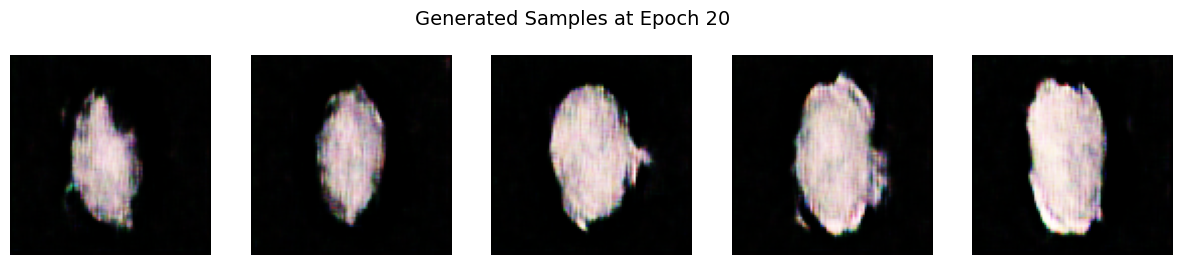

34/34 ━━━━━━━━━━━━━━━━━━━━ 6s 96ms/step - disc_loss: 1.3394 - gen_loss: 0.8506
Epoch 21/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 85ms/step - disc_loss: 1.3457 - gen_loss: 0.8525
Epoch 22/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - disc_loss: 1.3332 - gen_loss: 0.8444
Epoch 23/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - disc_loss: 1.3442 - gen_loss: 0.8534
Epoch 24/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 85ms/step - disc_loss: 1.3297 - gen_loss: 0.8767
Epoch 25/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 85ms/step - disc_loss: 1.3125 - gen_loss: 0.9085
Epoch 26/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - disc_loss: 1.3397 - gen_loss: 0.8485
Epoch 27/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - disc_loss: 1.3361 - gen_loss: 0.8477
Epoch 28/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - disc_loss: 1.3440 - gen_loss: 0.8434
Epoch 29/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - disc_loss: 1.3362 - gen_loss: 0.8773
Epoch 30/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - disc_loss: 1.3279 - gen_loss: 0.8947
E

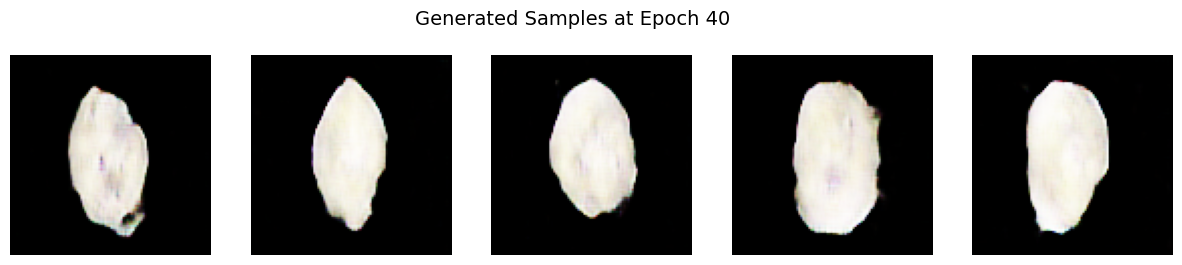

34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 91ms/step - disc_loss: 1.3677 - gen_loss: 0.8230
Epoch 41/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - disc_loss: 1.3712 - gen_loss: 0.8366
Epoch 42/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - disc_loss: 1.3736 - gen_loss: 0.8252
Epoch 43/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - disc_loss: 1.3757 - gen_loss: 0.8238
Epoch 44/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - disc_loss: 1.3667 - gen_loss: 0.8331
Epoch 45/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - disc_loss: 1.3642 - gen_loss: 0.8313
Epoch 46/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - disc_loss: 1.3675 - gen_loss: 0.7933
Epoch 47/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - disc_loss: 1.3583 - gen_loss: 0.8276
Epoch 48/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - disc_loss: 1.3610 - gen_loss: 0.8279
Epoch 49/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - disc_loss: 1.3658 - gen_loss: 0.8249
Epoch 50/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - disc_loss: 1.3606 - gen_loss: 0.8311
E

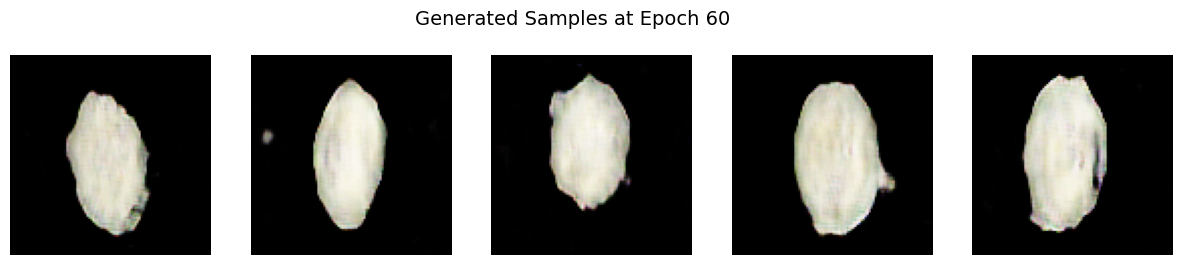

34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 88ms/step - disc_loss: 1.3579 - gen_loss: 0.8274
Epoch 61/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - disc_loss: 1.3681 - gen_loss: 0.8123
Epoch 62/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - disc_loss: 1.3578 - gen_loss: 0.8291
Epoch 63/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - disc_loss: 1.3607 - gen_loss: 0.8270
Epoch 64/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - disc_loss: 1.3640 - gen_loss: 0.8299
Epoch 65/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 85ms/step - disc_loss: 1.3674 - gen_loss: 0.8233
Epoch 66/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - disc_loss: 1.3565 - gen_loss: 0.8326
Epoch 67/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - disc_loss: 1.3547 - gen_loss: 0.8238
Epoch 68/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - disc_loss: 1.3716 - gen_loss: 0.8239
Epoch 69/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 85ms/step - disc_loss: 1.3625 - gen_loss: 0.8434
Epoch 70/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - disc_loss: 1.3549 - gen_loss: 0.8301
E

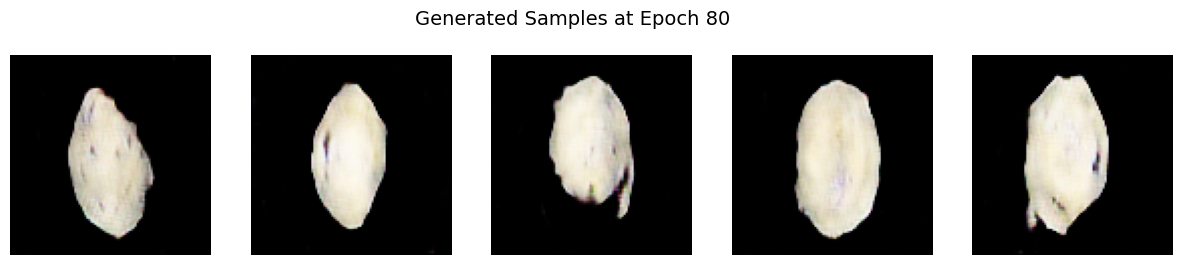

34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - disc_loss: 1.3549 - gen_loss: 0.8326
Epoch 81/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - disc_loss: 1.3527 - gen_loss: 0.8416
Epoch 82/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - disc_loss: 1.3508 - gen_loss: 0.8428
Epoch 83/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - disc_loss: 1.3565 - gen_loss: 0.8254
Epoch 84/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - disc_loss: 1.3614 - gen_loss: 0.8227
Epoch 85/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - disc_loss: 1.3576 - gen_loss: 0.8285
Epoch 86/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - disc_loss: 1.3598 - gen_loss: 0.8527
Epoch 87/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - disc_loss: 1.3513 - gen_loss: 0.8545
Epoch 88/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - disc_loss: 1.3556 - gen_loss: 0.8266
Epoch 89/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - disc_loss: 1.3461 - gen_loss: 0.8317
Epoch 90/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - disc_loss: 1.3517 - gen_loss: 0.8386
E

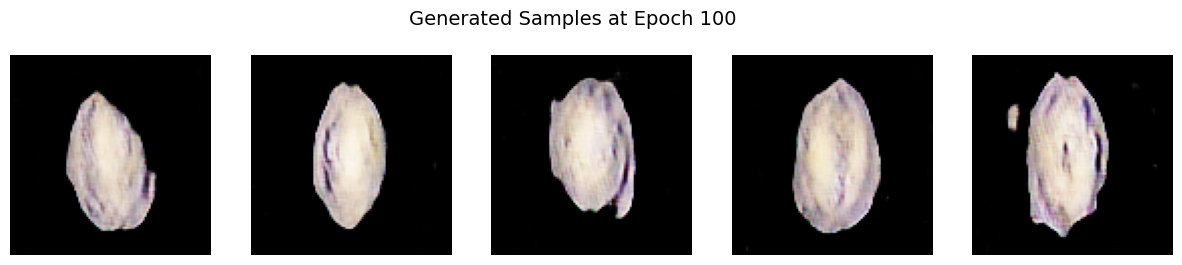

34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 90ms/step - disc_loss: 1.3540 - gen_loss: 0.8364
Epoch 101/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - disc_loss: 1.3487 - gen_loss: 0.8422
Epoch 102/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - disc_loss: 1.3558 - gen_loss: 0.8379
Epoch 103/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - disc_loss: 1.3594 - gen_loss: 0.8457
Epoch 104/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - disc_loss: 1.3505 - gen_loss: 0.8496
Epoch 105/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - disc_loss: 1.3458 - gen_loss: 0.8481
Epoch 106/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - disc_loss: 1.3479 - gen_loss: 0.8443
Epoch 107/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - disc_loss: 1.3457 - gen_loss: 0.8286
Epoch 108/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - disc_loss: 1.3455 - gen_loss: 0.8431
Epoch 109/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - disc_loss: 1.3440 - gen_loss: 0.8386
Epoch 110/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - disc_loss: 1.3565 - gen_loss

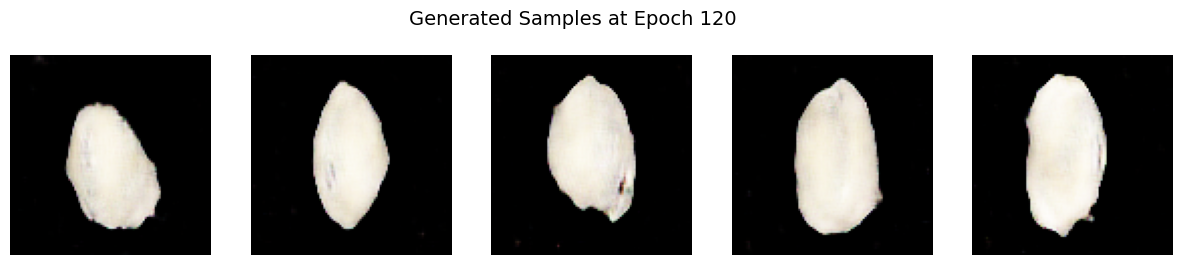

34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 88ms/step - disc_loss: 1.3541 - gen_loss: 0.8427
Epoch 121/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - disc_loss: 1.3403 - gen_loss: 0.8462
Epoch 122/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - disc_loss: 1.3544 - gen_loss: 0.8512
Epoch 123/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - disc_loss: 1.3442 - gen_loss: 0.8415
Epoch 124/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - disc_loss: 1.3596 - gen_loss: 0.8474
Epoch 125/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - disc_loss: 1.3460 - gen_loss: 0.8455
Epoch 126/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - disc_loss: 1.3546 - gen_loss: 0.8425
Epoch 127/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - disc_loss: 1.3350 - gen_loss: 0.8463
Epoch 128/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - disc_loss: 1.3453 - gen_loss: 0.8544
Epoch 129/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - disc_loss: 1.3511 - gen_loss: 0.8465
Epoch 130/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - disc_loss: 1.3402 - gen_loss

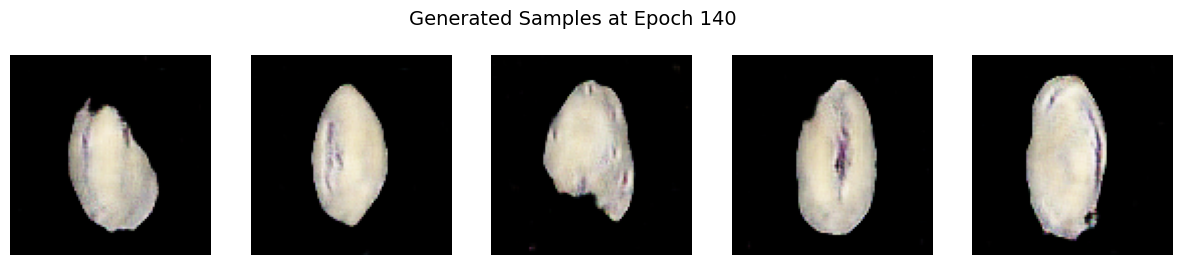

34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 87ms/step - disc_loss: 1.3328 - gen_loss: 0.8420
Epoch 141/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - disc_loss: 1.3494 - gen_loss: 0.8511
Epoch 142/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - disc_loss: 1.3469 - gen_loss: 0.8489
Epoch 143/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - disc_loss: 1.3442 - gen_loss: 0.8660
Epoch 144/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - disc_loss: 1.3856 - gen_loss: 0.8776
Epoch 145/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - disc_loss: 1.3578 - gen_loss: 0.8683
Epoch 146/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - disc_loss: 1.3433 - gen_loss: 0.8632
Epoch 147/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - disc_loss: 1.3451 - gen_loss: 0.8575
Epoch 148/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - disc_loss: 1.3292 - gen_loss: 0.8564
Epoch 149/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - disc_loss: 1.3402 - gen_loss: 0.8481
Epoch 150/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - disc_loss: 1.3477 - gen_loss

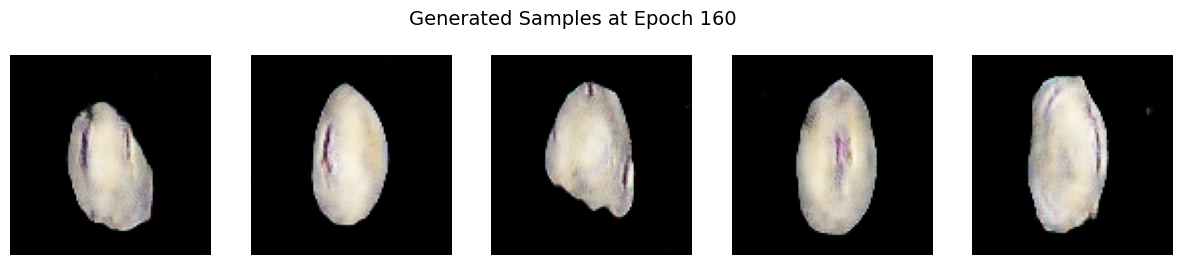

34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 88ms/step - disc_loss: 1.3421 - gen_loss: 0.8717
Epoch 161/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - disc_loss: 1.3199 - gen_loss: 0.8580
Epoch 162/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - disc_loss: 1.3384 - gen_loss: 0.8477
Epoch 163/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - disc_loss: 1.3421 - gen_loss: 0.8527
Epoch 164/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - disc_loss: 1.3348 - gen_loss: 0.8634
Epoch 165/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - disc_loss: 1.3327 - gen_loss: 0.8574
Epoch 166/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - disc_loss: 1.3257 - gen_loss: 0.8583
Epoch 167/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - disc_loss: 1.3291 - gen_loss: 0.8549
Epoch 168/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - disc_loss: 1.3454 - gen_loss: 0.8527
Epoch 169/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - disc_loss: 1.3278 - gen_loss: 0.8627
Epoch 170/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - disc_loss: 1.3171 - gen_loss

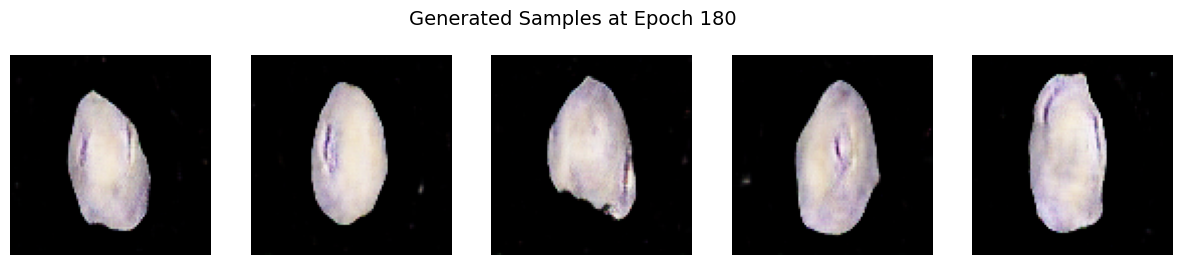

34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 87ms/step - disc_loss: 1.3121 - gen_loss: 0.8654
Epoch 181/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - disc_loss: 1.3684 - gen_loss: 0.9499
Epoch 182/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - disc_loss: 1.3503 - gen_loss: 0.9096
Epoch 183/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - disc_loss: 1.3267 - gen_loss: 0.8791
Epoch 184/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - disc_loss: 1.3170 - gen_loss: 0.8757
Epoch 185/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - disc_loss: 1.3258 - gen_loss: 0.8813
Epoch 186/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - disc_loss: 1.3413 - gen_loss: 0.8887
Epoch 187/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - disc_loss: 1.3201 - gen_loss: 0.8701
Epoch 188/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - disc_loss: 1.3176 - gen_loss: 0.8849
Epoch 189/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - disc_loss: 1.3155 - gen_loss: 0.8746
Epoch 190/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - disc_loss: 1.3191 - gen_loss

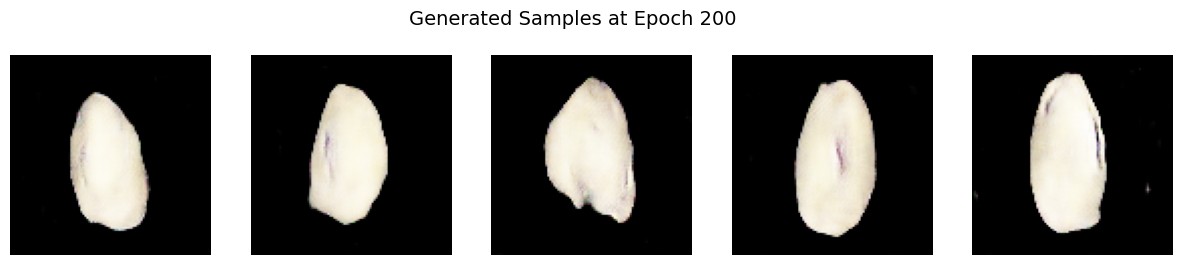

34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 87ms/step - disc_loss: 1.3030 - gen_loss: 0.8732


In [ ]:
monitor = GANSnapshotCallback(num_samples=5, latent_dim=noise_dim, save_every=20)

gan.fit(
    real_images,
    epochs=200,
    batch_size=32,  # up sizing the batch size
    callbacks=[monitor]
)

## Evaluate Modify Model

In [ ]:
inception_model = InceptionV3(include_top=False, pooling='avg', input_shape=(299, 299, 3))

def calculate_fid(model, real_images, fake_images):
    real_resized = np.array([cv2.resize(img, (299, 299)) for img in real_images])
    fake_resized = np.array([cv2.resize(img, (299, 299)) for img in fake_images])

    real_resized = preprocess_input(real_resized.astype(np.float32))
    fake_resized = preprocess_input(fake_resized.astype(np.float32))

    act1 = model.predict(real_resized, batch_size=32, verbose=0)
    act2 = model.predict(fake_resized, batch_size=32, verbose=0)

    mu1, sigma1 = act1.mean(axis=0), np.cov(act1, rowvar=False)
    mu2, sigma2 = act2.mean(axis=0), np.cov(act2, rowvar=False)
    diff = mu1 - mu2
    covmean, _ = sqrtm(sigma1 @ sigma2, disp=False)

    if np.iscomplexobj(covmean):
        covmean = covmean.real

    return diff @ diff + np.trace(sigma1 + sigma2 - 2 * covmean)

def evaluate_modified_fid(generator, real_images, noise_dim=100, sample_size=1000):
    real_images_sample = real_images[:sample_size].astype(np.float32)
    if real_images_sample.max() > 1.0:
        real_images_sample = real_images_sample / 255.0

    noise = np.random.normal(0, 1, (sample_size, noise_dim))
    gen_imgs = generator.predict(noise, batch_size=32, verbose=0)
    gen_imgs = 0.5 * gen_imgs + 0.5  # [-1,1] → [0,1]

    fid = calculate_fid(inception_model, real_images_sample, gen_imgs)
    print(f"FID Score (Modified Generator): {fid:.2f}")
    return fid

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# call function evaluate
evaluate_modified_fid(generator, real_images)

FID Score (Modified Generator): 102.41


np.float64(102.41316165886435)

Modified 2 introduced an important change by reducing the discriminator’s learning rate to 0.0001 while keeping the generator’s learning rate at 0.0002. Additionally, the number of training epochs and the save interval were reduced. These changes made the discriminator less dominant, allowing the generator more opportunity to learn. This configuration resulted in the best FID score of 102, suggesting a better balance between the two models and an improvement in the quality of generated images.

## Conclusion

Based on the series of experiments, it can be concluded that the most effective configuration was found in Modified 2, which used a slightly slower learning rate for the discriminator (0.0001) while maintaining a higher learning rate for the generator (0.0002). This setup achieved the lowest FID score of 102, suggesting that reducing the discriminator’s learning speed allowed the generator to learn more effectively and produce better-quality images. Attempts to improve results by increasing the number of epochs (Modified 3 and 4) did not lead to consistent improvements and, in some cases, even degraded performance, indicating that simply training for longer is not sufficient if the learning dynamics are unbalanced. Further modification by reducing batch size in Modified 5 showed some influence on training behavior, but still failed to outperform Modified 2. These results imply that the current training strategy has reached its limits, and future improvements are more likely to come from architectural enhancements to the generator, rather than continued tuning of hyperparameters alone.